In [1]:
import requests

url = "https://instagram120.p.rapidapi.com/api/instagram/posts"

payload = {
	"username": "keke",
	"maxId": ""
}
headers = {
	"x-rapidapi-key": "YOUR_RAPIDAPI_KEY_HERE",
	"x-rapidapi-host": "instagram120.p.rapidapi.com",
	"Content-Type": "application/json"
}

response = requests.post(url, json=payload, headers=headers)

print(response.json())

{'result': {'edges': [{'node': {'code': 'DUmMg6QkmIR', 'pk': '3829803571261628945', 'id': '3829803571261628945_1141197', 'ad_id': None, 'boosted_status': None, 'boost_unavailable_identifier': None, 'boost_unavailable_reason': None, 'caption': {'has_translation': None, 'created_at': 1770828827, 'pk': '17911738125316989', 'text': 'All They Type 😏\n\nVisualizer out now: YouTube.com/@KeyTVNetwork (Link in bio)'}, 'caption_is_edited': True, 'feed_demotion_control': None, 'feed_recs_demotion_control': None, 'taken_at': 1770768269, 'inventory_source': None, 'video_versions': [{'width': 720, 'height': 1280, 'url': 'https://instagram.fsof11-1.fna.fbcdn.net/o1/v/t16/f2/m69/AQPSkF2ot9TWJl9yoMX6q32iNW8GxEkEv5xEbN7LEkCbiqo-_m4rot7GcZYOjUqgY4zOMtRIoaZCfjWk1RW6ZLqc.mp4?strext=1&_nc_cat=103&_nc_oc=Admj2dugO24cnvRPJZCPaAqSRt0zGDXvRe4Pd77_SY4mvp7V56Z0fTY8LphIxIkutfE&_nc_sid=5e9851&_nc_ht=instagram.fsof11-1.fna.fbcdn.net&_nc_ohc=4yNei0rNnVAQ7kNvwG_V_Fl&efg=eyJ2ZW5jb2RlX3RhZyI6Inhwdl9wcm9ncmVzc2l2ZS5JTlNU

In [ ]:
import requests
import pandas as pd

# 1. Configuration
url = "https://instagram120.p.rapidapi.com/api/instagram/posts"

# The API requires a payload (the body of the request) to know which user to search
payload = {
    "username": "keke",
    "maxId": ""
}

headers = {
    "x-rapidapi-key": "YOUR_RAPIDAPI_KEY_HERE", # REMINDER: Rotate this key in your dashboard soon!
    "x-rapidapi-host": "instagram120.p.rapidapi.com",
    "Content-Type": "application/json" # Required when sending a JSON payload
}

# 2. Fetch the Data
try:
    # CHANGED: We are now using requests.post() and passing the json=payload
    response = requests.post(url, json=payload, headers=headers)
    response.raise_for_status() # Check for HTTP errors
    data = response.json()
    
    # 3. Process Data (Normalize JSON to Table)
    # Depending on how the API structures its response, we might need to dig into a specific key.
    # We will try to flatten the raw data first.
    df = pd.json_normalize(data) 
    
    # 4. Save to CSV
    csv_filename = "keke_instagram_dataset.csv"
    df.to_csv(csv_filename, index=False)
    print(f"Success! Data saved to {csv_filename}")

except requests.exceptions.RequestException as e:
    print(f"API Request failed: {e}")
    # This will print the exact reason the API rejected it, if available
    if 'response' in locals() and response.text:
        print(f"API Error Details: {response.text}")
except Exception as e:
    print(f"An error occurred: {e}")

In [2]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("keke_instagram_dataset.csv")



In [3]:
df.head()

,result.edges,result.page_info.end_cursor,result.page_info.has_next_page,result.page_info.has_previous_page,result.page_info.start_cursor,result.version
0,"[{'node': {'code': 'DUmMg6QkmIR', 'pk': '38298...",3834733206956999104_1141197,True,False,NaN,v1


In [4]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
df = pd.read_csv("keke_instagram_dataset.csv")

print("--- Initial Data Overview ---")
print(f"Total Posts (Rows): {len(df)}")
print(f"Total Features (Columns): {len(df.columns)}\n")

# 2. Dynamically locate important columns
# API responses change often, so we search for keywords rather than hardcoding names
def find_column(dataframe, keyword):
    for col in dataframe.columns:
        if keyword in col.lower():
            return col
    return None

likes_col = find_column(df, 'like')
comments_col = find_column(df, 'comment')
caption_col = find_column(df, 'text') # Usually 'caption.text'

# 3. Feature Engineering (Adding AI/ML value)
if caption_col:
    # Fill empty captions to prevent code crashes
    df[caption_col] = df[caption_col].fillna("")
    
    # Extract new features for NLP or predictive modeling
    df['caption_length'] = df[caption_col].apply(len)
    df['hashtag_count'] = df[caption_col].apply(lambda x: str(x).count('#'))
    print("✅ Feature Engineering Complete: Added 'caption_length' and 'hashtag_count'.")

# 4. Data Cleaning & Aggregation
if likes_col and comments_col:
    # Convert empty values (NaN) to 0 and ensure they are numbers
    df[likes_col] = pd.to_numeric(df[likes_col], errors='coerce').fillna(0).astype(int)
    df[comments_col] = pd.to_numeric(df[comments_col], errors='coerce').fillna(0).astype(int)
    
    # Create a composite 'Total Engagement' metric
    df['total_engagement'] = df[likes_col] + df[comments_col]
    
    # Sort the dataframe to surface the highest-performing posts
    df = df.sort_values(by='total_engagement', ascending=False)

    print("\n--- Top 3 Most Engaging Posts ---")
    # Truncate the caption text so it prints nicely in the terminal
    display_df = df.copy()
    display_df[caption_col] = display_df[caption_col].str[:50] + "..." 
    print(display_df[[caption_col, likes_col, 'total_engagement']].head(3))

# 5. Export the ML-ready dataset
output_filename = "keke_processed_for_kaggle.csv"
df.to_csv(output_filename, index=False)
print(f"\n🚀 Success! Processed dataset saved to '{output_filename}'")

--- Initial Data Overview ---
Total Posts (Rows): 1
Total Features (Columns): 6


🚀 Success! Processed dataset saved to 'keke_processed_for_kaggle.csv'


In [6]:
import pandas as pd

# Load the raw dataset we got directly from the API
df = pd.read_csv("keke_instagram_dataset.csv")

print("Here are the EXACT column names in your dataset:\n")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Here are the EXACT column names in your dataset:

0: result.edges
1: result.page_info.end_cursor
2: result.page_info.has_next_page
3: result.page_info.has_previous_page
4: result.page_info.start_cursor
5: result.version


In [7]:
import pandas as pd
import ast

# 1. Load the original CSV where the data is trapped
df_raw = pd.read_csv("keke_instagram_dataset.csv")

# 2. Extract the massive string of trapped posts from the first row
trapped_data_string = df_raw['result.edges'].iloc[0]

try:
    # 3. Convert that string back into a readable Python list
    posts_list = ast.literal_eval(trapped_data_string)
    
    # 4. Normalize the REAL list of posts!
    df_unlocked = pd.json_normalize(posts_list)
    
    # 5. Save the properly formatted data
    new_filename = "keke_unlocked.csv"
    df_unlocked.to_csv(new_filename, index=False)
    
    print(f"✅ Success! Data unpacked and saved to {new_filename}\n")
    print("--- Your NEW Unlocked Columns ---")
    
    # Let's print the first 20 columns so we can see the actual metrics
    for i, col in enumerate(df_unlocked.columns[:20]):
        print(f"{i}: {col}")

except Exception as e:
    print(f"❌ Error unpacking data: {e}")

✅ Success! Data unpacked and saved to keke_unlocked.csv

--- Your NEW Unlocked Columns ---
0: cursor
1: node.code
2: node.pk
3: node.id
4: node.ad_id
5: node.boosted_status
6: node.boost_unavailable_identifier
7: node.boost_unavailable_reason
8: node.caption.has_translation
9: node.caption.created_at
10: node.caption.pk
11: node.caption.text
12: node.caption_is_edited
13: node.feed_demotion_control
14: node.feed_recs_demotion_control
15: node.taken_at
16: node.inventory_source
17: node.video_versions
18: node.is_dash_eligible
19: node.number_of_qualities


🔍 Found Caption Column: node.caption.text
🔍 Found Likes Column: node.like_and_view_counts_disabled
🔍 Found Comments Column: node.comment_count

✅ Engineered new features: 'hashtag_count' and 'caption_length'
✅ Calculated 'total_engagement'

🚀 Final dataset saved and ready for Kaggle: keke_final_kaggle_dataset.csv
✅ Plot saved as 'engagement_plot.png'


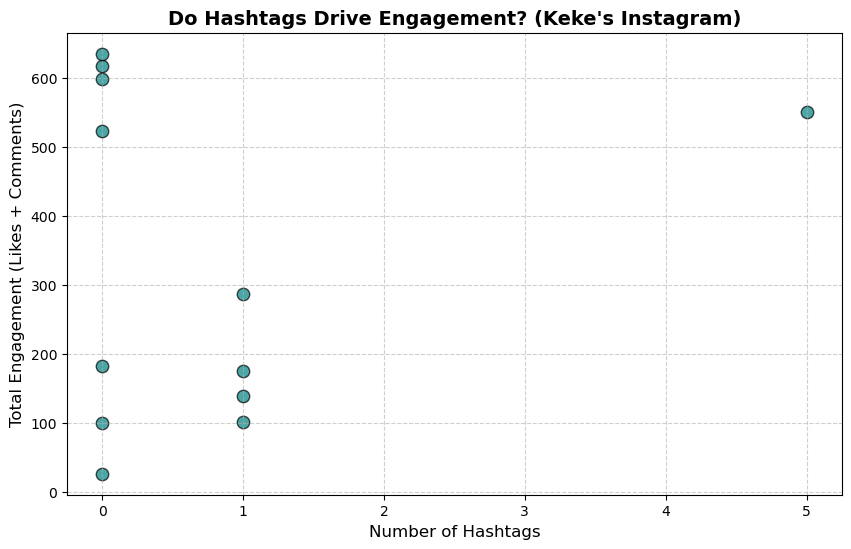

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the unlocked dataset
df = pd.read_csv("keke_unlocked.csv")

# 2. Identify the exact columns 
caption_col = 'node.caption.text'

# Helper function to find where the API hid the likes and comments
def find_column(dataframe, keyword):
    for col in dataframe.columns:
        if keyword in col.lower():
            return col
    return None

likes_col = find_column(df, 'like')
comments_col = find_column(df, 'comment')

print(f"🔍 Found Caption Column: {caption_col}")
print(f"🔍 Found Likes Column: {likes_col}")
print(f"🔍 Found Comments Column: {comments_col}\n")

# 3. Feature Engineering (NLP Prep)
if caption_col in df.columns:
    # Fill missing text with empty strings so the code doesn't crash
    df[caption_col] = df[caption_col].fillna("")
    
    # Extract hashtag count and caption length
    df['hashtag_count'] = df[caption_col].apply(lambda x: str(x).count('#'))
    df['caption_length'] = df[caption_col].apply(lambda x: len(str(x)))
    print("✅ Engineered new features: 'hashtag_count' and 'caption_length'")

# 4. Calculate Total Engagement
if likes_col and comments_col:
    # Clean the numerical data (convert to numbers, fill missing with 0)
    df[likes_col] = pd.to_numeric(df[likes_col], errors='coerce').fillna(0).astype(int)
    df[comments_col] = pd.to_numeric(df[comments_col], errors='coerce').fillna(0).astype(int)
    
    # Create the target variable
    df['total_engagement'] = df[likes_col] + df[comments_col]
    print("✅ Calculated 'total_engagement'")
    
    # 5. Save the final processed dataset for Kaggle
    final_csv = "keke_final_kaggle_dataset.csv"
    
    # Keep only the most useful columns to make the Kaggle dataset clean
    useful_cols = [
        'node.id', 'node.taken_at', caption_col, 
        likes_col, comments_col, 'hashtag_count', 
        'caption_length', 'total_engagement'
    ]
    
    # Filter only the columns that actually exist in our dataframe
    cols_to_save = [col for col in useful_cols if col in df.columns]
    
    df[cols_to_save].to_csv(final_csv, index=False)
    print(f"\n🚀 Final dataset saved and ready for Kaggle: {final_csv}")

    # 6. Data Visualization
    plt.figure(figsize=(10, 6))
    plt.scatter(df['hashtag_count'], df['total_engagement'], color='teal', alpha=0.7, edgecolors='black', s=80)
    
    plt.title("Do Hashtags Drive Engagement? (Keke's Instagram)", fontsize=14, fontweight='bold')
    plt.xlabel("Number of Hashtags", fontsize=12)
    plt.ylabel("Total Engagement (Likes + Comments)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Save and show the plot
    plt.savefig("engagement_plot.png", bbox_inches='tight')
    print("✅ Plot saved as 'engagement_plot.png'")
    plt.show()

else:
    print("❌ Could not automatically find the likes or comments columns.")